In [ ]:
# Install required libraries
!pip install artemis
!pip install pyartemis


In [ ]:
!pip install alibi

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, SVR
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import VotingClassifier
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.cluster import KMeans
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from scipy import stats

In [ ]:
from sklearn.decomposition import PCA
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
from sklearn.model_selection import GridSearchCV


In [ ]:
df=pd.read_csv('cardio_train.csv',sep=";")
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1


# Preprocessing

In [ ]:
df.duplicated().sum()

0

In [ ]:
df.isnull().sum()

,0
id,0
age,0
gender,0
height,0
weight,0
ap_hi,0
ap_lo,0
cholesterol,0
gluc,0
smoke,0


In [ ]:
df.dtypes

,0
id,int64
age,int64
gender,int64
height,int64
weight,float64
ap_hi,int64
ap_lo,int64
cholesterol,int64
gluc,int64
smoke,int64


In [ ]:
df['age']=(df['age']/365.25).round()
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,50.0,2,168,62.0,110,80,1,1,0,0,1,0
1,1,55.0,1,156,85.0,140,90,3,1,0,0,1,1
2,2,52.0,1,165,64.0,130,70,3,1,0,0,0,1
3,3,48.0,2,169,82.0,150,100,1,1,0,0,1,1
4,4,48.0,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,53.0,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,62.0,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,52.0,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,61.0,1,163,72.0,135,80,1,2,0,0,0,1


In [ ]:
# Get all categorical columns
categorical_columns = df.select_dtypes(include=['object', 'category']).columns
print("Categorical Columns:", categorical_columns)

Categorical Columns: Index([], dtype='object')


# EDA

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  float64
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(2), int64(11)
memory usage: 6.9 MB


In [ ]:
df.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,53.303157,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,6.760171,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,30.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,48.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,54.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,58.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,65.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
df['cardio'].value_counts()

,cardio
0,35021
1,34979


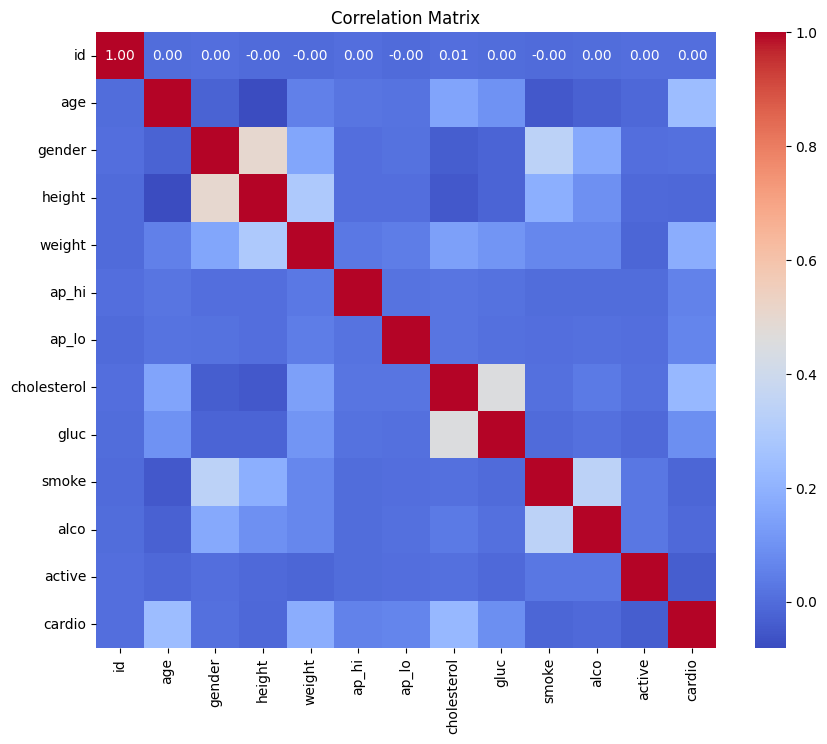

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [ ]:
df['bmi'] = df['weight'] / ((df['height']/100)**2)
df = df[(df['bmi'] >= 15) & (df['bmi'] <= 50)]

In [ ]:

df['pulse_pressure'] = df['ap_hi'] - df['ap_lo']
df['hypertension'] = ((df['ap_hi'] >= 140) | (df['ap_lo'] >= 90)).astype(int)
df['obesity'] = (df['bmi'] >= 30).astype(int)

df = df.drop(columns=['height', 'weight', 'ap_hi', 'ap_lo','id'])



<ipython-input-16-294a61a843f7>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['pulse_pressure'] = df['ap_hi'] - df['ap_lo']
<ipython-input-16-294a61a843f7>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['hypertension'] = ((df['ap_hi'] >= 140) | (df['ap_lo'] >= 90)).astype(int)
<ipython-input-16-294a61a843f7>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: h

In [ ]:
x = df.drop('cardio', axis = 1)
y = df['cardio']

# Ensemble Stacked Neural Network Mode

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)

In [ ]:
from imblearn.combine import SMOTEENN

In [ ]:
smotenn = SMOTEENN(random_state=42)
X_scaled, y= smotenn.fit_resample(X_scaled, y)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=0)

In [ ]:
# first we need to make base nn
nn_clf = Sequential([
    Dense(128, activation='relu', input_shape=(x_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])
nn_clf.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
nn_clf.fit(
    x_train, y_train,
    validation_data=(x_test,y_test),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
610/610 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9317 - loss: 0.2082 - val_accuracy: 0.9639 - val_loss: 0.1146
Epoch 2/50
610/610 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9587 - loss: 0.1231 - val_accuracy: 0.9641 - val_loss: 0.1080
Epoch 3/50
610/610 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9585 - loss: 0.1209 - val_accuracy: 0.9641 - val_loss: 0.1099
Epoch 4/50
610/610 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9610 - loss: 0.1205 - val_accuracy: 0.9623 - val_loss: 0.1123
Epoch 5/50
610/610 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9618 - loss: 0.1178 - val_accuracy: 0.9619 - val_loss: 0.1105
Epoch 6/50
610/610 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9595 - loss: 0.1227 - val_accuracy: 0.9641 - val_loss: 0.1051
Epoch 7/50
610/610 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9630 - loss: 0.1108 - val_accuracy: 0.9629 - val_loss: 0.1079
Epoch 8/50
610/610 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9618 - loss: 0.1175 - val_accuracy: 0.

In [ ]:
train_preds=nn_clf.predict(x_train)
test_preds=nn_clf.predict(x_test)


610/610 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
X_train_stack=np.hstack((x_train, train_preds))
X_test_stack=np.hstack((x_test, test_preds))

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
model_params = {
    'LogisticRegression': {
        'model':LogisticRegression(),
        'params': {'C': [0.01, 0.1, 1, 10, 100]}
    },
    'svm': {
        'model':SVC(),
        'params': {'C':[0.01, 0.1, 1, 10, 100]}
    },
    'knn': {
        'model':KNeighborsClassifier(),
        'params':{'n_neighbors':[3, 5, 7, 9]}
    },
    'Gaussian NB': {
        'model': GaussianNB(),
        'params': {}

    },
    'Decision Tree Classifier': {
        'model': DecisionTreeClassifier(),
        'params': {
            'min_samples_split': [2, 5, 10],
            'max_depth': [3, 5, 10, None]
        }
    },
    'RandomForest': {
        'model': RandomForestClassifier(),
        'params': {
            'max_features': [ 'sqrt', 'log2'],
            'n_estimators': [50, 100, 200]
        }
    },
    'gb': {
        'model': GradientBoostingClassifier(),
        'params': {
            'learning_rate': [0.01, 0.1, 0.3],
            'n_estimators': [50, 100, 200]
        }
    },
    'AdaBoostClassifier': {
        'model': AdaBoostClassifier(),
        'params': {
            'learning_rate': [0.01, 0.1, 0.3],
            'n_estimators': [50, 100, 200]
        }
    },
    'xgb': {
        'model': XGBClassifier(),
        'params': {
            'learning_rate': [0.01, 0.1, 0.3],
            'n_estimators': [50, 100, 200]
        }
    }
}

In [ ]:
best_models = {}
for name,mp in model_params.items():
    print(f"Training {name.upper()}.")
    clf = GridSearchCV(mp['model'],mp['params'], cv=3, scoring='accuracy', n_jobs=-1)
    clf.fit(x_train, y_train)
    best_models[name] = clf.best_estimator_
    print(f"Best parameters for {name.upper()}: {clf.best_params_}")

Training LOGISTICREGRESSION.
Best parameters for LOGISTICREGRESSION: {'C': 10}
Training SVM.
Best parameters for SVM: {'C': 100}
Training KNN.
Best parameters for KNN: {'n_neighbors': 3}
Training GAUSSIAN NB.
Best parameters for GAUSSIAN NB: {}
Training DECISION TREE CLASSIFIER.
Best parameters for DECISION TREE CLASSIFIER: {'max_depth': None, 'min_samples_split': 2}
Training RANDOMFOREST.
Best parameters for RANDOMFOREST: {'max_features': 'sqrt', 'n_estimators': 100}
Training GB.
Best parameters for GB: {'learning_rate': 0.3, 'n_estimators': 200}
Training ADABOOSTCLASSIFIER.
Best parameters for ADABOOSTCLASSIFIER: {'learning_rate': 0.3, 'n_estimators': 200}
Training XGB.
Best parameters for XGB: {'learning_rate': 0.3, 'n_estimators': 200}


In [ ]:
estimators = [(name, model) for name, model in best_models.items()]

In [ ]:
RF=RandomForestClassifier()

In [ ]:
from sklearn.ensemble import StackingClassifier
SC = StackingClassifier(estimators=estimators,final_estimator=RF,cv=5)
SC.fit(X_train_stack, y_train)


StackingClassifier(cv=5,
                   estimators=[('LogisticRegression', LogisticRegression(C=10)),
                               ('svm', SVC(C=100)),
                               ('knn', KNeighborsClassifier(n_neighbors=3)),
                               ('Gaussian NB', GaussianNB()),
                               ('Decision Tree Classifier',
                                DecisionTreeClassifier()),
                               ('RandomForest', RandomForestClassifier()),
                               ('gb',
                                GradientBoostingClassifier(learning_rate=0.3,
                                                           n_estimators=200)),
                               ('AdaBoostC...
                                              interaction_constraints=None,
                                              learning_rate=0.3, max_bin=None,
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None,
                                              max_depth=None, max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=200, n_jobs=None,
                                              num_parallel_tree=None,
                                              random_state=None, ...))],
                   final_estimator=RandomForestClassifier())

In [ ]:
y_pred=SC.predict(X_test_stack)
print("Accuracy:",accuracy_score(y_test, y_pred))

Accuracy: 0.9840032813781788


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      2415
           1       0.98      0.99      0.98      2461

    accuracy                           0.98      4876
   macro avg       0.98      0.98      0.98      4876
weighted avg       0.98      0.98      0.98      4876



In [ ]:
from sklearn.model_selection import learning_curve

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
5 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py", line 63, in inner_f
    return f(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/ensemble/_stacking.py", line 717, in fit
    return super().fit(X, y_encoded, **fit_params)
           ^

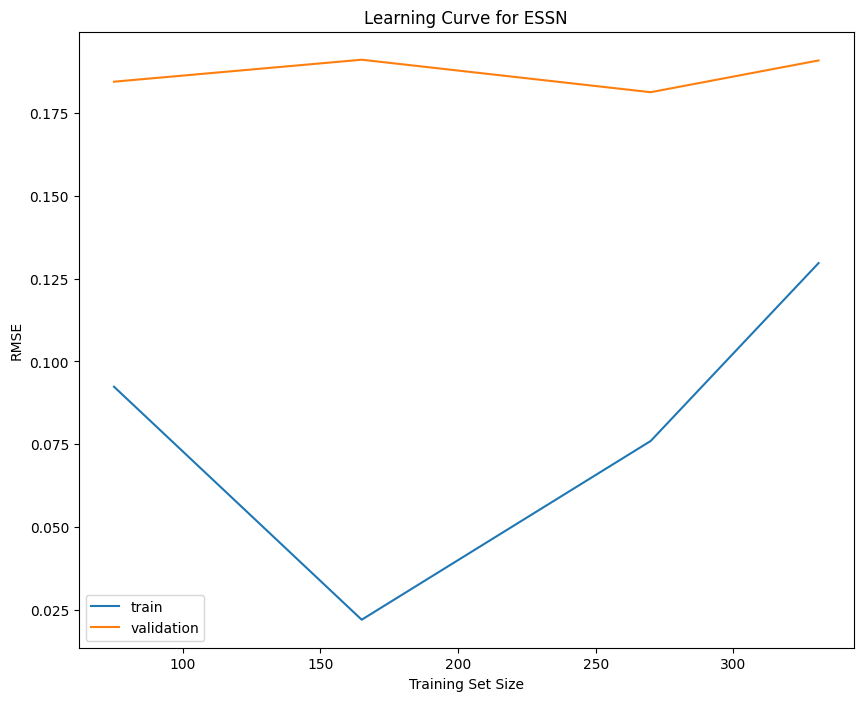

In [ ]:
train_sizes, train_scores, test_scores = learning_curve(
    estimator=SC,
    X=X_train_stack,
    y=y_train,
    cv=5,
    scoring="neg_root_mean_squared_error",
    train_sizes = [1, 75, 165, 270, 331]
)

train_mean = -train_scores.mean(axis=1)
test_mean = -test_scores.mean(axis=1)

plt.subplots(figsize=(10,8))
plt.plot(train_sizes, train_mean, label="train")
plt.plot(train_sizes, test_mean, label="validation")

plt.title("Learning Curve for ESSN")
plt.xlabel("Training Set Size")
plt.ylabel("RMSE")
plt.legend(loc="best")

plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, precision_recall_curve, roc_curve, auc

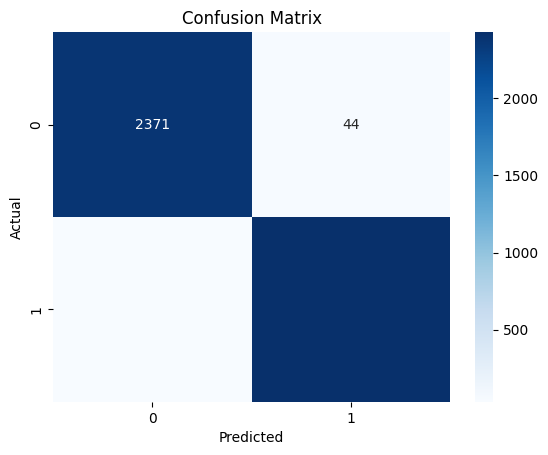

In [ ]:
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

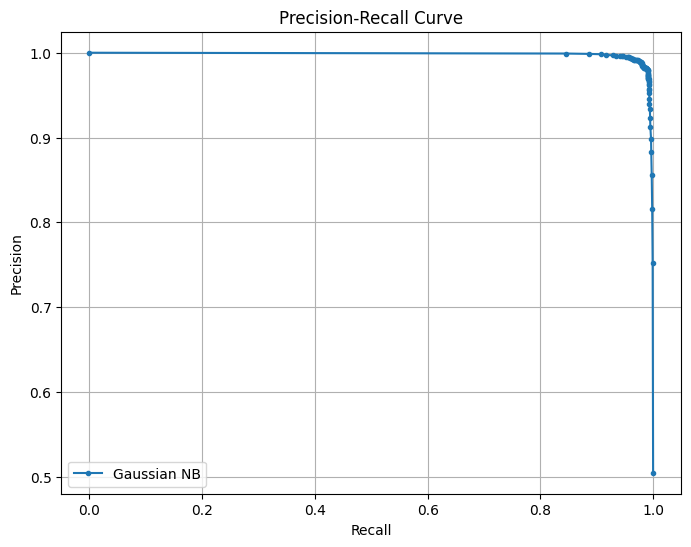

In [ ]:
# Generate predicted probabilities
y_probs_clf = SC.predict_proba(X_test_stack)[:, 1]

# Compute precision and recall
precision, recall, thresholds = precision_recall_curve(y_test, y_probs_clf)

# Plot Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker=".", label="Gaussian NB")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid()
plt.show()

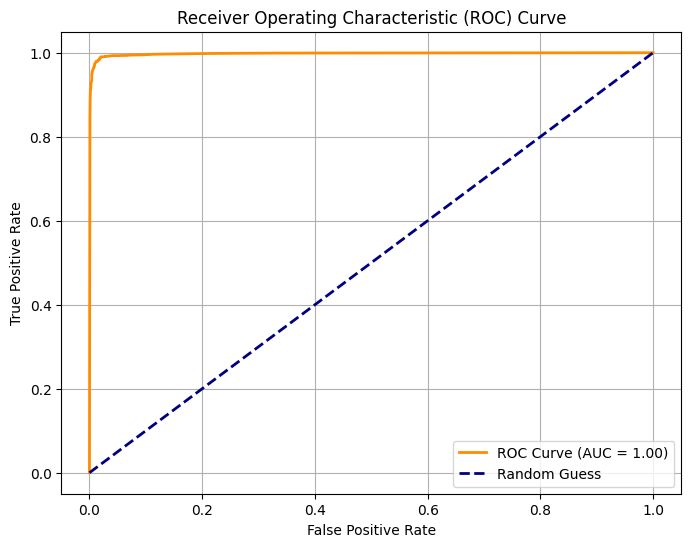

In [ ]:
# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_probs_clf)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.grid()
plt.show()

# **Permutation Feature Importance**

In [ ]:
X_df = pd.DataFrame(X_scaled, columns=x.columns)

In [ ]:
from sklearn.inspection import permutation_importance

result = permutation_importance(SC, X_test_stack, y_test, n_repeats=10, random_state=42)
importances_mean = result.importances_mean
sorted_idx = importances_mean.argsort()


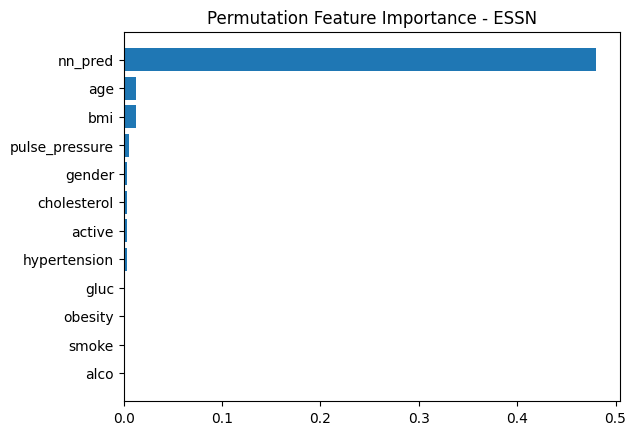

In [ ]:
feature_names = list(x.columns) + ['nn_pred']
sorted_features = [feature_names[i] for i in sorted_idx]

plt.barh(sorted_features, importances_mean[sorted_idx])
plt.title("Permutation Feature Importance - ESSN")
plt.show()

# **ALE**

In [ ]:
from alibi.explainers import ALE
from alibi.explainers.ale import plot_ale


In [ ]:
feature = ['age','gender','cholesterol','gluc','smoke','alco','active','bmi','pulse_pressure','hypertension','obesity']

In [ ]:
proba_fun_gnb = SC.predict_proba
proba_ale_gnb = ALE(proba_fun_gnb, feature_names=feature, target_names=["class 0", "class 1"])
proba_exp_gnb = proba_ale_gnb.explain(X_train_stack)

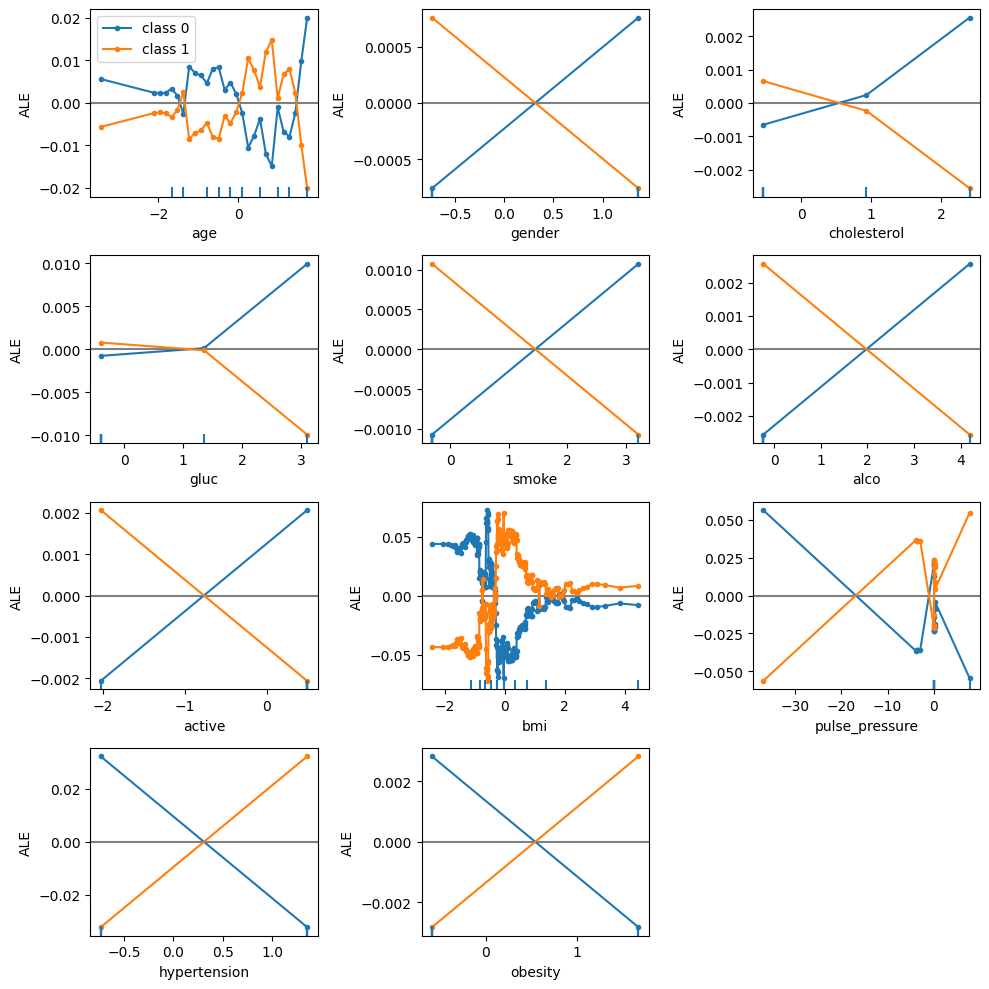

In [ ]:
plot_ale(proba_exp_gnb, n_cols=3, fig_kw={'figwidth': 10, 'figheight': 10}, sharey=None);

# **PDP**

In [ ]:
from sklearn.inspection import PartialDependenceDisplay

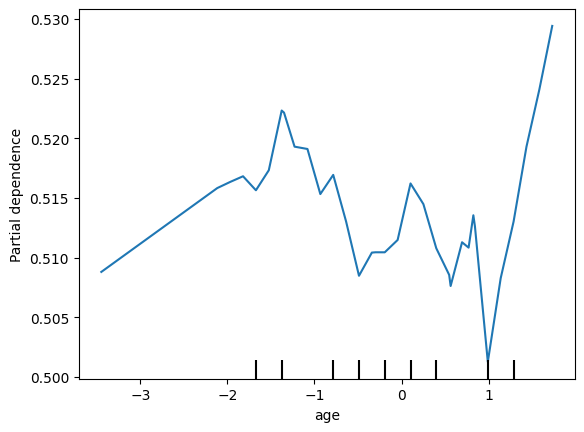

In [ ]:
features = [0]
PartialDependenceDisplay.from_estimator(SC,X_test_stack, features,feature_names=feature)

# **ICE**

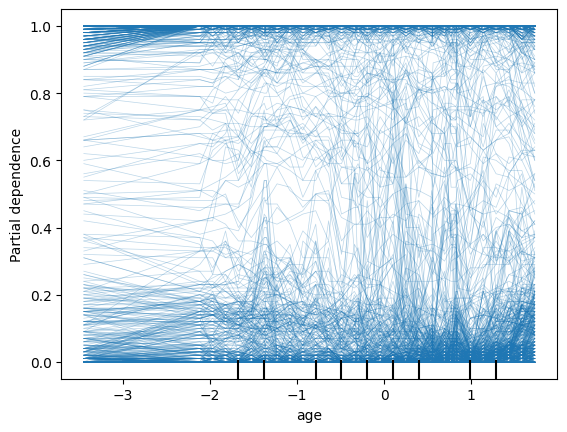

In [ ]:
features = [0]
PartialDependenceDisplay.from_estimator(SC,X_test_stack, features,feature_names=feature, kind='individual')

# **FriedmanHStatistic**

In [ ]:
import random
from artemis.interactions_methods.model_agnostic import FriedmanHStatisticMethod


In [ ]:
random.seed(8)
X_exp = random.choices(X_scaled, k=100)
X_exp = pd.DataFrame(X_exp, columns=X_df.columns)

In [ ]:
X_exp_df = pd.DataFrame(X_exp, columns=x.columns)
exp_preds = nn_clf.predict(X_exp)
X_exp_df['nn_pred'] = exp_preds

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


In [ ]:
h_stat = FriedmanHStatisticMethod()
h_stat.fit(SC, X_exp_df)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but GaussianNB was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but 

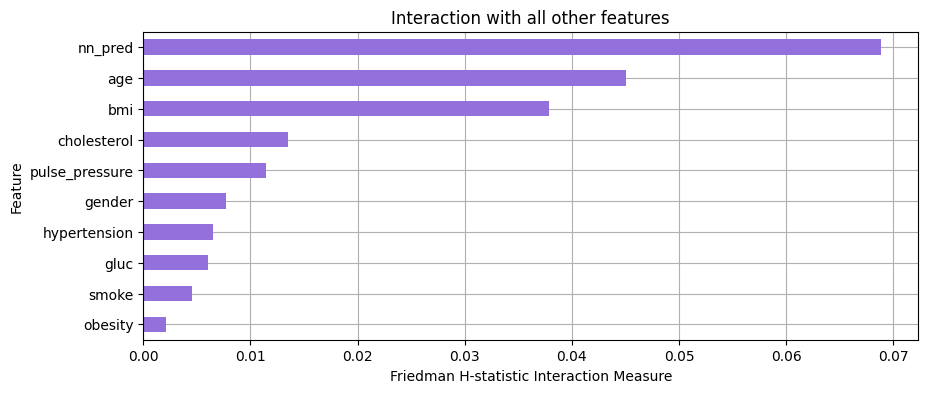

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
h_stat.plot('bar_chart_ova', ax=ax)
plt.show()

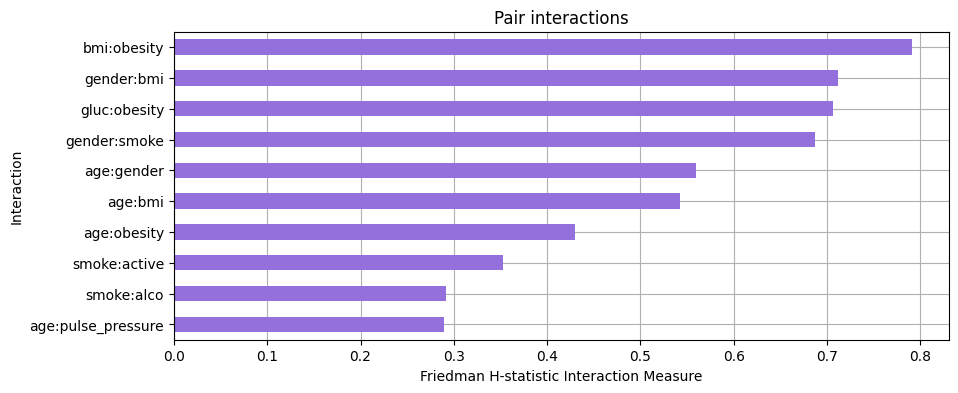

In [ ]:
# Pairwise interactions
fig, ax = plt.subplots(figsize=(10, 4))
h_stat.plot(vis_type='bar_chart',ax=ax)

# **LIME**

In [ ]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 14.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=748baed2803385e3dfa9c9a83849727e4612b354aa2066a263cb83e7b04cab05
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


In [ ]:
import lime
from lime.lime_tabular import LimeTabularExplainer


In [ ]:
original_features = list(x.columns)
feature_names = original_features + ['nn_pred']

In [ ]:
explainer = LimeTabularExplainer(training_data=X_train_stack,feature_names=feature_names,class_names=['no_disease', 'disease'],mode='classification')

In [ ]:
i = 0
exp = explainer.explain_instance(
    X_test_stack[i],
    SC.predict_proba,
    num_features=10
)
exp.show_in_notebook(show_table=True)


In [ ]:
i = 5
exp = explainer.explain_instance(
    X_test_stack[i],
    SC.predict_proba,
    num_features=10
)
exp.show_in_notebook(show_table=True)
